# Tutorial 2: Running NMF on the Repele2605 Dataset

In this tutorial you will use **non-negative matrix factorization (NMF)** to find patterns in a real gene-expression time-series dataset. 

By the end, you will have:

- Loaded an RNA-sequencing dataset (thousands of genes measured over time, under two experimental conditions).
- Cleaned and rescaled the data so it's ready for analysis.
- Run NMF to summarize the data as a small number of reusable expression patterns, called **metagenes**.
- Saved your results to files and produced a 3D visualization of what NMF found.

**Before you start:** this notebook assumes you've completed [Tutorial 1](../../tutorials/Tutorial1_GettingStarted.ipynb) and have it open in Jupyter Lab, with the `NMF` conda environment active as its kernel (you can check this in the top-right corner of the window — it should say `Python 3 (ipykernel)` or similar, running from your `NMF` environment).

## How to use a Jupyter notebook

A notebook is a document made of **cells**. There are two kinds you'll see here:

- **Markdown cells** (like this one) contain formatted text — explanations, headings, links. They don't do anything when run except display nicely.
- **Code cells** contain Python code. When you run one, the code actually executes.

**To run a cell:** click on it, then press **Shift+Enter**. This runs the cell and moves you to the next one. You'll see a `[ ]` to the left of every code cell turn into a number, like `[1]`, showing it has run — and the number tells you the *order* in which cells were executed.

**A few important habits for beginners:**

- All the code cells in a notebook share one running Python session, called the **kernel**. Variables you create in one cell are still available in later cells.
- Run cells **in order, from top to bottom**, the first time through. Skipping around can cause confusing errors because a later cell might expect a variable that an earlier cell hasn't created yet.
- If things get confusing (errors that don't make sense, or you want a clean slate), use the menu **Kernel > Restart Kernel and Clear Outputs of All Cells**, then run everything again from the top with **Run > Run All Cells**.

Let's try it. Click the code cell below and press **Shift+Enter**.

In [1]:
message = "Jupyter is working!"
print(message)

Jupyter is working!


You should have seen `Jupyter is working!` appear below the cell, and the `[ ]` next to it turned into `[1]`. That's it — that's the whole interaction model. Now let's get to the real analysis.

## Part 1: Understanding the data and the goal

**The data.** The dataset in this tutorial (from Repele et al.) measures **gene expression** — how active each gene is — for about 36,000 genes, at many time points, in blood-forming cells that were treated with one of two signaling molecules: **GCSF** or **IL3**. Think of each gene as having its own "activity level" that can go up or down over time as the cell responds to the treatment; we measured that activity level repeatedly, from before treatment (time = -48 hours) to a week later (time = 168 hours).

So the raw data is enormous: 36,000+ genes × dozens of timepoints × 2 conditions. Making sense of it by eye is hopeless — we need a way to summarize it.

**The goal: NMF.** **Non-negative matrix factorization (NMF)** is a mathematical technique for summarizing a large table of numbers (that are never negative — like gene expression, which can't be less than zero) using a small number of reusable *patterns*. In this context, a pattern is called a **metagene**: a single, characteristic way that expression rises and falls over time. NMF looks at all 36,000 genes at once and asks: "can I describe every single one of these genes' behavior over time as some combination of just a handful of shared patterns?"

Concretely, NMF takes our big data table $X$ (genes × samples) and approximates it as the product of two smaller tables:

$$X \approx W \times H$$

- $W$ (genes × metagenes) says how strongly *each gene* participates in *each metagene*.
- $H$ (metagenes × samples) says how *each metagene's* activity changes over time and condition.

Instead of 36,000 independent stories, we end up with a handful of representative "behaviors" ($H$) and a map of which genes follow which behavior ($W$) — much easier to interpret and discuss.

## Part 2: Setup

This notebook lives in `example/Repele2605/`, two folders below the repository root, but the data files and the helper code we need are organized relative to the repository root. So the first thing we do is move Python's "current working directory" up two levels, to the root of the `NMF` repository.

Then we import everything from **`GeneData.py`** — a helper file included in this repository that defines all the functions we'll use in this tutorial (things like `Load_Dataset`, `filter_low_expressing_genes`, `NMF`, and the plotting functions). Writing `from GeneData import *` brings all of those functions into this notebook so we can call them directly, without typing `GeneData.` in front of every one.

In [2]:
import os
os.chdir('../..')
print(f"Changed directory to {os.getcwd()}")

Changed directory to /Users/manu/lib/NMF_github


In [3]:
from GeneData import *

If you saw a message like `Matplotlib is building the font cache; this may take a moment.` — that's normal. It only happens the first time a plotting library is used on a computer, and it isn't an error.

## Part 3: Load and explore the gene expression data

### Download the data

The data files are too big to be hosted on github. Download the data from the cloud (you would have been provided a link) and copy the files `Repele2605RNASeqTimeSeries.csv` and `Repele2605GeneNames.csv` to the `example/Repele2605` directory of the repository.

The raw data lives in a CSV (comma-separated values) file, in what's called **long format**: instead of one row per gene, there is one row for *every combination* of gene, timepoint, and condition. So a single gene that was measured at 29 timepoints in 2 conditions takes up 58 rows.

The function `Load_Dataset` reads that CSV file and returns the data as a NumPy **structured array** — you can think of it like a spreadsheet you can access by column name (e.g. `data["expression"]`) instead of by column number.

In [4]:
data = Load_Dataset('example/Repele2605/Repele2605RNASeqTimeSeries.csv')

Let's peek at what we just loaded, so the structure is concrete rather than abstract.

In [5]:
print("Columns available:", data.dtype.names)
print("Total number of rows:", len(data))
print("\nFirst 3 rows:")
for row in data[:3]:
    print(row)

Columns available: ('timepoints', 'geneNames', 'expression', 'sd', 'condition')
Total number of rows: 1994025

First 3 rows:
(-48.0, 'Trdd2', 0.0, 0.0, 'GCSF-OHT')
(-48.0, 'Trdd1', 0.0, 0.0, 'GCSF-OHT')
(-48.0, 'Trbd1', 0.0, 0.0, 'GCSF-OHT')


Each column is: the timepoint (in hours, with pre-treatment being negative), the gene's name, its measured expression value, a standard deviation, and which condition (`GCSF-OHT` or `IL3-OHT`) it was measured under.

### Getting the list of gene names

Next we need a clean list of every gene name in the dataset, without duplicates. A convenient way to do this: since every gene has a measurement at timepoint -48 under the `GCSF-OHT` condition, we can filter the data down to just those rows — each remaining row then corresponds to exactly one gene.

This is a good moment to introduce **boolean masks**, a core NumPy idea you'll see throughout this notebook. Writing `data["timepoints"] == -48` doesn't return a single true/false — it compares *every row* to `-48` at once, giving back an array of `True`/`False` values, one per row. `np.logical_and` combines two such arrays position-by-position (both must be `True`). We then use that combined array to pick out just the rows we want, the same way you'd use a spreadsheet filter.

In [7]:
time = data["timepoints"] == -48        # True for rows measured at timepoint -48
cond = data["condition"] == "GCSF-OHT"  # True for rows measured under GCSF-OHT
GList = np.logical_and(time, cond)      # True only where both conditions hold
geneNames = data["geneNames"][GList].tolist()  # the full, ordered list of gene names

print("Number of genes:", len(geneNames))
print("First 5 gene names:", geneNames[:5])

Number of genes: 36255
First 5 gene names: ['Trdd2', 'Trdd1', 'Trbd1', 'Trbd2', 'Ighd4-1']


### Pulling out the expression values

Now we use the helper function `exprs` to pull out, for each condition, a table of expression values (genes × timepoints) plus the list of timepoints measured. We pass in `geneNames` (our full, ordered gene list) and `False` for the last argument, which tells `exprs` to grab expression values for *all* genes in that condition rather than a specific subset.

In [8]:
gcsf = exprs(geneNames, 'GCSF-OHT', data, False)  # timepoints and expression values, GCSF-OHT condition
il3 = exprs(geneNames, 'IL3-OHT', data, False)    # timepoints and expression values, IL3-OHT condition

print("GCSF-OHT: ", len(gcsf[0]), "timepoints,", gcsf[1].shape, "(timepoints x genes) expression table")
print("IL3-OHT:  ", len(il3[0]), "timepoints,", il3[1].shape, "(timepoints x genes) expression table")

GCSF-OHT:  29 timepoints, (29, 36255) (timepoints x genes) expression table
IL3-OHT:   26 timepoints, (26, 36255) (timepoints x genes) expression table


### Assembling the combined data matrix

We would like to perform NMF jointly across the GCSF and IL3 data. This way metagenes will capture correlations across conditions, for example genes that are upregulated in GCSF but downregulated in IL3 would grouped separately from genes that are upregulated in both conditions. 

Therefore, we need to combine the GCSF and IL3 tables into one. We stack them along the timepoint axis (so all 29 GCSF timepoints come first, followed by all 26 IL3 timepoints), then **transpose** the result so that **rows are genes** and **columns are samples** (a sample = one timepoint under one condition). This gene-rows / sample-columns layout is the convention NMF expects, and the one we'll use for the rest of this tutorial.

In [9]:
Xgt = np.concatenate((gcsf[1], il3[1]), 0)
Xgt = Xgt.T

print(f"Xgt shape: {Xgt.shape[0]} genes x {Xgt.shape[1]} samples (timepoints x conditions)")

Xgt shape: 36255 genes x 55 samples (timepoints x conditions)


## Part 4: Cleaning the data before analysis

### Filter out genes that never really turn on

Many genes in a genome-wide dataset are essentially silent — low, noisy measurements that never reach a meaningful expression level in any sample. Including them doesn't help NMF find real patterns; it just adds noise and slows things down. `filter_low_expressing_genes` removes any gene whose **maximum** expression value, across all samples, doesn't exceed a threshold (here, `5.0`).

In [10]:
XgtFilt, geneNamesFilt = filter_low_expressing_genes(Xgt, geneNames, 5.0)

print(f"Genes before filtering: {Xgt.shape[0]}")
print(f"Genes after filtering:  {XgtFilt.shape[0]}")

Genes before filtering: 36255
Genes after filtering:  15378


### Scale each gene to a [0, 1] range

Different genes are expressed at wildly different absolute levels — some routinely produce far more transcript than others, for reasons that have nothing to do with the *pattern* of their expression over time. If we handed NMF the raw numbers, the highest-expressed genes would dominate the fit simply because their numbers are bigger, not because their temporal pattern is more important. `scaleGeneExpression` divides each gene's row by its own maximum, so every gene's expression now ranges from 0 to 1 — putting all genes on equal footing and letting NMF focus on the *shape* of each gene's trajectory rather than its scale.

In [11]:
XgtFiltScaled = scaleGeneExpression(XgtFilt)

## Part 5: Run NMF

Now for the main event. We call the `NMF` function with three arguments:

- `XgtFiltScaled` — our cleaned, scaled data matrix.
- `10` — the number of metagenes ($K$) to summarize the data with. This is a modeling choice: too few metagenes and you lose important distinctions between genes; too many and the "patterns" stop being distinct or interpretable. 10 is the value used in the original study for this dataset.
- `0.005` — the convergence tolerance. NMF works iteratively: it starts from a random guess for $W$ and $H$, then repeatedly nudges them to make $W \times H$ a little closer to $X$. After each round, it measures the remaining error using the **Frobenius norm** — a single number summarizing the total difference between the real data $X$ and the current approximation $W \times H$ (smaller is a better fit). Once that number stops improving by more than `0.005` between rounds, we consider it converged and stop.

This returns three things: the weights matrix `Wgm` (genes × metagenes), the behaviors matrix `Hmt` (metagenes × samples), and `frobNorm`, the history of the Frobenius norm at every iteration, which we plot to check that the fit actually converged.

**This step does the real computational work and may take a minute or two** — you'll see the iteration count and current Frobenius norm update in place while it runs.

iteration=334   FrobNorm=72.6070060347603


Text(0.5, 1.0, 'Convergence of Frobenius norm')

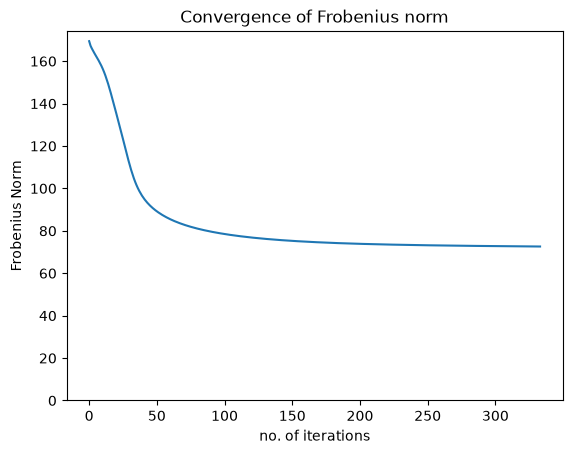

In [12]:
Wgm, Hmt, frobNorm = NMF(XgtFiltScaled, 10, 0.005)

plt.plot(frobNorm)
plt.ylim(bottom=0)
plt.xlabel("no. of iterations")
plt.ylabel("Frobenius Norm")
plt.title("Convergence of Frobenius norm")

**Reading this plot:** the Frobenius norm should drop steeply at first (NMF is quickly moving away from its random starting guess) and then flatten out (it's found a stable summary and further iterations barely change it). A curve that levels off like this is a good sign that the fit has converged; if it were still dropping steeply at the end, we'd want to lower the tolerance or run more iterations.

## Part 6: Save the results

NMF starts from a random initial guess, so running it again will give slightly different (though similarly good) metagenes. To make sure we can revisit *this particular* result later — for further analysis, sharing with a colleague, or writing up a paper — we save the key outputs to CSV files: the weights (`Wgm.csv`), the behaviors (`Hmt.csv`), the cleaned data matrix (`XgtFiltScaled.csv`), and the filtered gene names (`geneNamesFilt.txt`). These will be written into the `example/Repele2605/` folder, alongside this notebook.

In [13]:
with open('example/Repele2605/Wgm.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["1","2","3","4","5","6","7","8","9","10"])
    writer.writerows(Wgm)
with open('example/Repele2605/Hmt.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["-48","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","96","104","112","120","128","136","144","152","160","168","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","104","112","120","128","136","152","160","168"])
    writer.writerows(Hmt)
with open('example/Repele2605/XgtFiltScaled.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["-48","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","96","104","112","120","128","136","144","152","160","168","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","104","112","120","128","136","152","160","168"])
    writer.writerows(Xgt)
geneNamesFiltArr = np.array(geneNamesFilt)
np.savetxt('example/Repele2605/geneNamesFilt.txt', geneNamesFiltArr, fmt="%s")

print("Saved Wgm.csv, Hmt.csv, XgtFiltScaled.csv, and geneNamesFilt.txt")

Saved Wgm.csv, Hmt.csv, XgtFiltScaled.csv, and geneNamesFilt.txt


## Part 7: Visualize NMF in 3D

Raw NMF output isn't easy to look at directly — `Wgm` alone has tens of thousands of rows, one per gene, in no particular order. To make a meaningful picture, we reorder ("sort") both the metagenes and the genes so that similar things end up next to each other:

1. **Sort the metagenes** by *when* their activity peaks — the metagene that turns on earliest becomes metagene 1, the one that turns on latest becomes the last one. This turns an arbitrary list of 10 patterns into an ordered progression over time.
2. **Sort the genes**, first by which metagene dominates them (i.e. which pattern they follow most strongly), and then by how strongly. Genes following the same pattern end up grouped together.

`sorted_Hmt_behaviors` does step 1, and also normalizes each metagene's behavior to a [0, 1] scale so they're visually comparable to each other despite differing in overall magnitude.

In [14]:
WgmSorted, HmtSorted, Hmt_beh_idx = sorted_Hmt_behaviors(Hmt, Wgm)

# Assign sorted Hmt behaviors for the two conditions separately (29 GCSF timepoints, then 26 IL3 timepoints)
GCSF_sorted_Hmt = HmtSorted[:,:29]
IL3_sorted_Hmt = HmtSorted[:,29:]

Now step 2, the **nested sort**: reordering the genes themselves based on the (now time-ordered) metagenes.

In [15]:
nested_sort_both_conditions = NMF_nested_sort(XgtFiltScaled, WgmSorted, HmtSorted, geneNamesFilt)

# Assign nested sorted Xgt values to variables for the two conditions separately
GCSF_nested_sorted_Xgt = nested_sort_both_conditions[0][:,:29]
IL3_nested_sorted_Xgt = nested_sort_both_conditions[0][:,29:]
Wgm_nested_sorted = nested_sort_both_conditions[1]
Hmt_nested_sorted = nested_sort_both_conditions[2]
sorted_indices = nested_sort_both_conditions[3]
sorted_gene_names = nested_sort_both_conditions[4]

### Draw the 3D figure

`NMF_sorted_visualization` draws a single figure with three connected "faces", like an unfolded box:

- **Top face — Gene expression $X_{gt}$:** the actual (sorted) measured data, genes down one side, timepoints along the other. Brighter = higher expression.
- **Left face — Weights $W_{gm}$:** for each gene, how strongly it belongs to each metagene. This is what determined the gene ordering on the top face.
- **Right face — Behaviors $H_{mt}$:** the 10 metagene patterns themselves, each shown as a filled curve over time — this is the actual "shape" of each summarized pattern.

Reading all three together: pick a band of genes on the top face, trace across to the left face to see which metagene they belong to, then look at that metagene's curve on the right face to see the behavior those genes are following over time.

We generate one figure for the GCSF condition and one for the IL3 condition, and save each as a PNG image.

#### GCSF condition

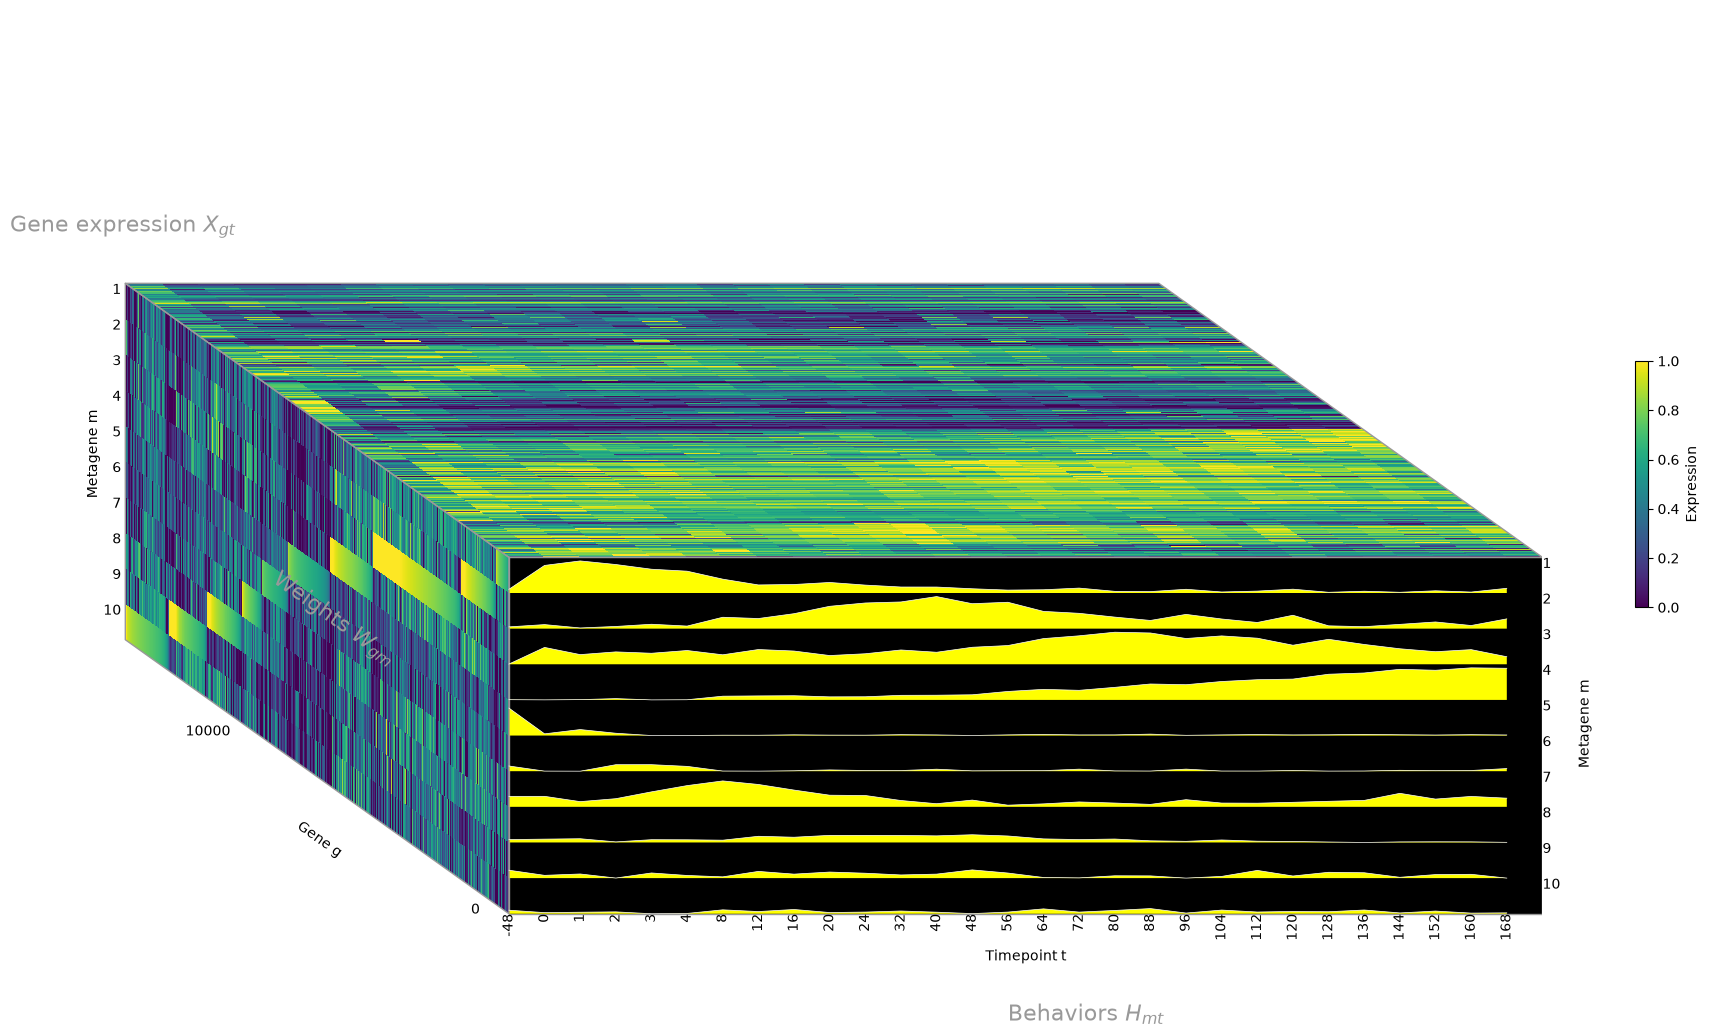

In [16]:
GCSF_sort_visualization = NMF_sorted_visualization(
    GCSF_nested_sorted_Xgt, Wgm_nested_sorted, GCSF_sorted_Hmt, gcsf[0],
    'example/Repele2605/NMF3DFilteredGCSF.png'
)

In [17]:
GCSF_sort_visualization.savefig('example/Repele2605/NMF3DFilteredGCSF.png', bbox_inches='tight', dpi=300)

#### IL3 condition

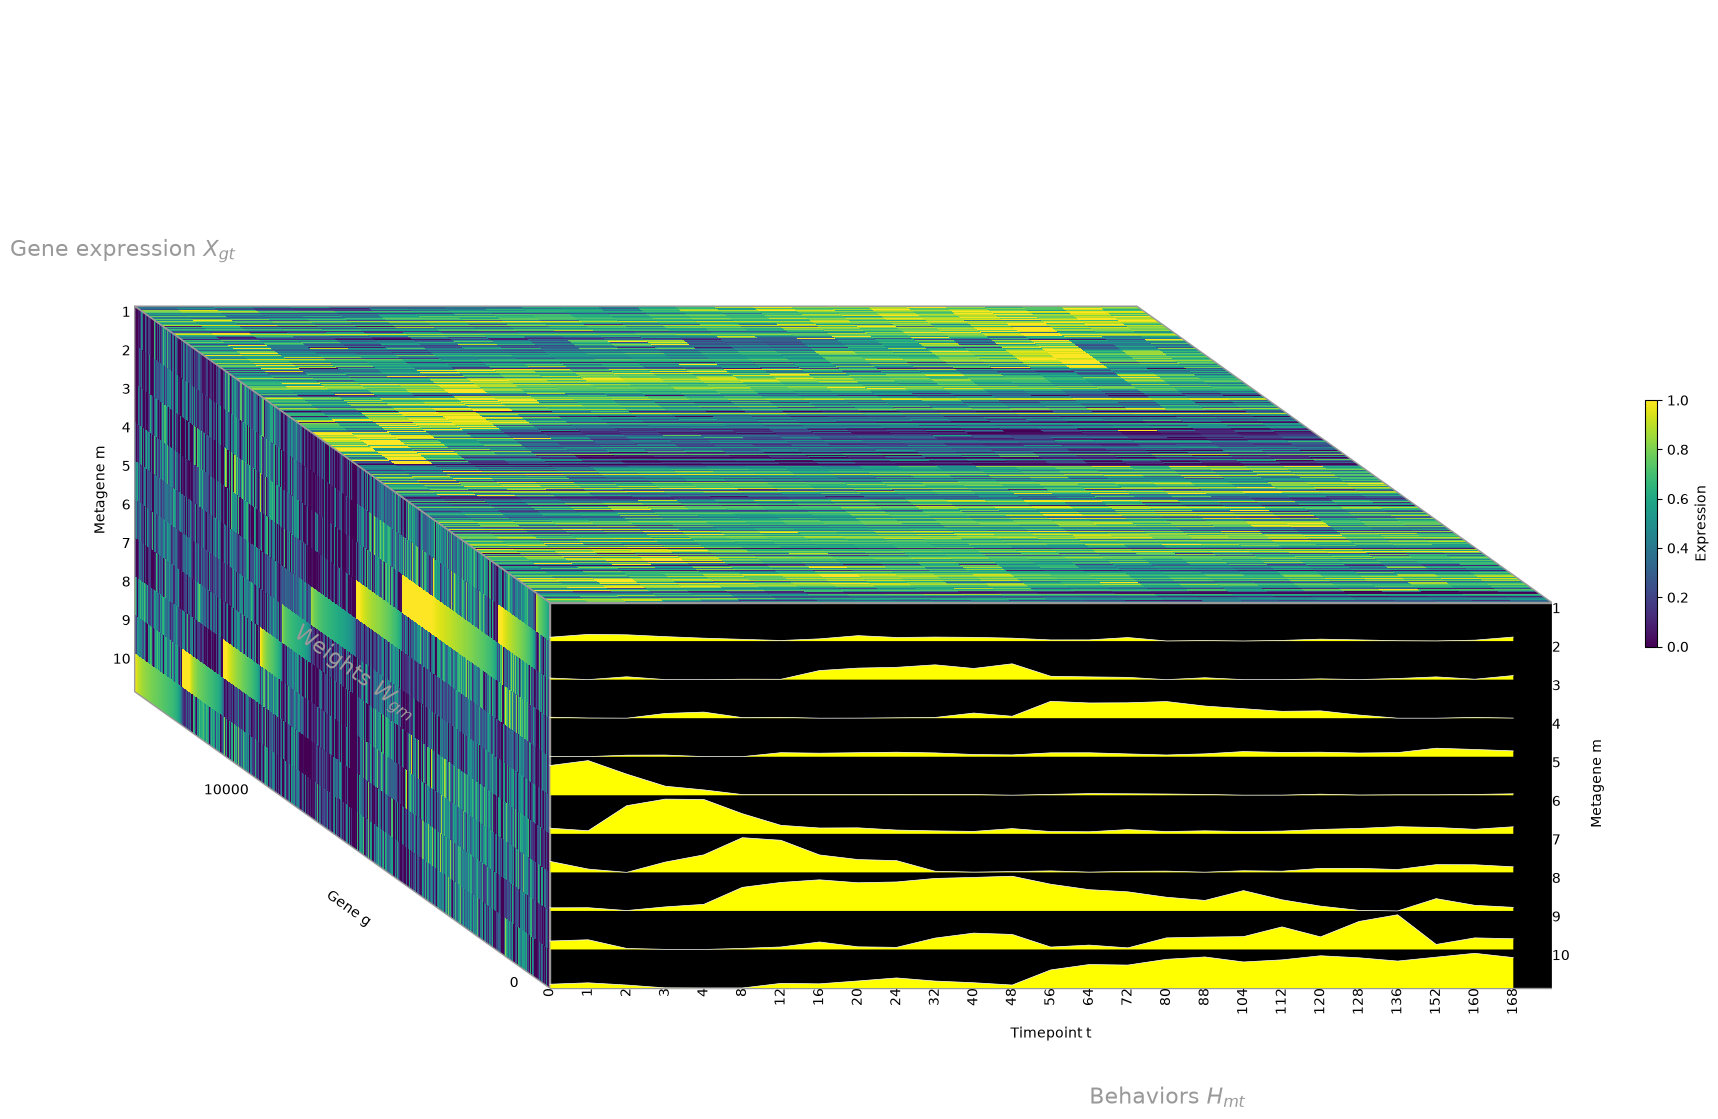

In [18]:
IL3_sort_visualization = NMF_sorted_visualization(
    IL3_nested_sorted_Xgt, Wgm_nested_sorted, IL3_sorted_Hmt, il3[0],
    'example/Repele2605/NMF3DFilteredIL3.png'
)

In [19]:
IL3_sort_visualization.savefig('example/Repele2605/NMF3DFilteredIL3.png', bbox_inches='tight', dpi=300)

## What we did, and where to go next

Starting from a raw, long-format CSV of ~36,000 genes measured over time in two conditions, you:

1. Loaded and inspected the data.
2. Assembled it into a single gene × sample matrix.
3. Filtered out low-expressing genes and rescaled the rest to a common [0, 1] range.
4. Ran NMF to summarize the data as 10 metagenes, and checked that it converged.
5. Saved the results to CSV files for reuse.
6. Produced a 3D visualization showing the data, the gene weights, and the metagene behaviors together.

**Ideas to explore next**, all using tools already imported into this notebook:

- **Try a different number of metagenes.** Rerun Part 5 with `NMF(XgtFiltScaled, 5, 0.005)` or `NMF(XgtFiltScaled, 20, 0.005)` and compare — do the behaviors in the right-hand face of the 3D plot look more or less distinct?
- **Try a different expression threshold** in Part 4 (e.g. `10.0` instead of `5.0`) and see how many genes remain, and whether the metagene shapes change.
- **Look up a specific gene you're interested in.** `sorted_gene_names` (from Part 7) gives you the final gene ordering; you can find a gene's position with `sorted_gene_names.index("YourGeneName")` and use `NMF_sort` (also defined in `GeneData.py`) to see which metagene dominates it.
- **Bring your own dataset.** If you can format your data as a long-format CSV like `Repele2605RNASeqTimeSeries.csv` (one row per gene/timepoint/condition, with columns `timepoints, geneNames, expression, sd, condition`), every function in this notebook will work on it unchanged.